# 

In [ ]:
import re
from os import PathLike
from typing import Tuple
import pandas as pd
from collections import Counter
from jinja2 import Environment, FileSystemLoader
from tqdm import tqdm
from Bio import SeqIO

# E-value cutoff for HMM scan confidence.
E_VALUE_CUTOFF = 1e-6
# Map "HMM Name" to "Fold family".
FOLD_DICT = {
        'Alk_phosphatase': 'ALK',
        'CPDc_SM00577': 'HAD',
        'Chronophin_1': 'HAD',
        'Chronophin_2': 'HAD',
        'DSPc': 'CC1',
        'DSPc_SM00195': 'CC1',
        'DUF442': 'Unknown',
        'His_Phos_1': 'HP',
        'His_Phos_2': 'HP',
        'Init_tRNA_PT': 'CC1',
        'LMWPc': 'CC2',
        'LMWPc_SSU72': 'CC2',
        'LMWPc_SSU72_ArsC': 'CC2',
        'MDP_1': 'HAD',
        'MDP_2': 'HAD',
        'Myotub-related': 'CC1',
        'NIF': 'HAD',
        'PP2Ac_SM00156': 'PPPL',
        'PP2C': 'PPM',
        'PP2C_2': 'PPM',
        'PP2C_SIG_SM00331': 'PPM',
        'PP2Cc_SM00332': 'PPM',
        'PPM_PTC7': 'PPM',
        'PPM_PTC7_SpoIIE': 'PPM',
        'PPM_PTC7_motif': 'PPM',
        'PPP_1': 'PPPL',
        'PPP_2': 'PPPL',
        'PPP_3': 'PPPL',
        'PPP_4': 'PPPL',
        'PPP_5_Dcr2': 'PPPL',
        'PTEN_1': 'CC1',
        'PTPc_DSPc_SM00012': 'CC1',
        'PTPc_motif_SM00404': 'CC1',
        'PTPlike_phytase': 'CC1',
        'RHOD_SM00450': 'CC3',
        'RPAP2_Rtr1': 'RTR1',
        'Ssu72': 'CC2',
        'Y_phosphatase': 'CC1',
        'Y_phosphatase2': 'CC1',
        'Y_phosphatase3': 'CC1',
        'PPM_PTC7_SpoIIE_motif': 'PPM',
        'SpoIIE': 'PPM',
    }

def read_hmmscan_tblout(filepath: str| PathLike):
    """
    Read an hmmscan --tblout file into a pandas DataFrame.
    
    Skips comment lines (#) and parses the standard 18-column HMMER output.
    Returns a DataFrame with column names matching the hmmscan manual.
    """
    colnames = [
        "target_name", "target_accession",
        "query_name", "query_accession",
        "full_seq_Evalue", "full_seq_score", "full_seq_bias",
        "best_dom_Evalue", "best_dom_score", "best_dom_bias",
        "exp", "reg", "clu", "ov", "env", "dom", "rep", "inc",
        "description_of_target"
    ]
    numeric_cols = [
        "full_seq_Evalue", "full_seq_score", "full_seq_bias",
        "best_dom_Evalue", "best_dom_score", "best_dom_bias",
        "exp", "reg", "clu", "ov", "env", "dom", "rep", "inc"
    ]

    _df = pd.read_csv(
        filepath,
        comment="#",
        sep='\\s+',
        names=colnames,
        usecols=range(len(colnames))  # ignore any trailing extra whitespace
    )
    # convert numeric columns to floats/ints where appropriate
    _df[numeric_cols] = _df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    return _df


def classify_hmmscan(hmmscan_tbldf: pd.DataFrame, min_evalue=1e-6):
    """
    Classify HMMER hmmscan hits into confidence categories.

    This function takes the tabular output from `read_hmmscan_tblout`, filters out
    hits with very weak E-values, and assigns each hit to one of the following
    categories based on heuristic thresholds:

        - "High-confidence"
        - "Probable"
        - "Weak"
        - "Fragmentary"
        - "Ambiguous"
        - "No match"

    Parameters
    ----------
    hmmscan_tbldf : pandas.DataFrame
        DataFrame containing hmmscan results, as formatted by
        `read_hmmscan_tblout`. Must include the following columns:
        ``["full_seq_Evalue", "best_dom_Evalue", "best_dom_score", "best_dom_bias",
        "exp", "clu", "ov", "env", "rep", "inc"]``.
    min_evalue : float, optional
        Minimum full-sequence E-value threshold for filtering hits (default = 1e-6).

    Returns
    -------
    pandas.DataFrame
        A copy of the input DataFrame with an additional column ``"confidence"``
        containing the assigned category for each hit.

    Raises
    ------
    BaseException
        If one or more of the required columns are missing from the input DataFrame.

    Notes
    -----
    The classification scheme is heuristic and may need to be adjusted for
    specific datasets or applications.
    """
    _df = hmmscan_tbldf.copy()
    # Filter out very weak hits (full_seq_Evalue < 1e-6)
    _df = _df.loc[_df['full_seq_Evalue'] < min_evalue]
    expected_cols = [
        "full_seq_Evalue",
        "best_dom_Evalue", "best_dom_score", "best_dom_bias",
        "exp", "clu", "ov", "env", "rep", "inc",
    ]
    # Check if all of the required columns exists in the input dataframe.
    if set(expected_cols).intersection(set(_df.columns)) != set(expected_cols):
        raise BaseException('classify_hmmscan: Expected column(s) not found in dataframe.')

    def classify(row):
        full_e = row["full_seq_Evalue"]
        dom_e = row["best_dom_Evalue"]
        score = row["best_dom_score"]
        bias = row["best_dom_bias"]
        inc = row["inc"]
        rep = row["rep"]
        exp = row["exp"]
        env = row["env"]
        clu = row["clu"]
        ov = row["ov"]

        # Decision tree
        if full_e <= 1e-5:
            if inc >= 1:
                if dom_e <= 1e-3 and bias < 0.1 * score:
                    return "High-confidence"
                else:
                    return "Probable"
            else:
                if dom_e <= 1e-3 and rep >= 1:
                    return "Probable"
                elif exp >= 0.5 and env > 0:
                    return "Weak"
                else:
                    return "Fragmentary"
        else:
            if dom_e <= 1e-3 and inc >= 1:
                return "Probable"
            elif clu > 0 or ov > 0:
                return "Ambiguous"
            elif rep >= 1 and dom_e <= 1e-2:
                return "Weak"
            else:
                return "No match"

    _df["confidence"] = _df.apply(classify, axis=1)
    return _df


In [37]:
MOTIF_PATTERNS = {
    "CC1":   [
        {
            "pattern": r"HC[A-Z]{5}R",
            "match_type": "exact",
            "motif": "CC1",
            "description": "Canonical CC1 motif",
        },
        {
            "pattern": r"[A-Z]C[A-Z]{5}R",
            "match_type": "relaxed",
            "motif": "CC1",
            "description": "His mutated at position 1",
        },
        {
            "pattern": r"H[A-Z]{6}R", # only R conserved
            "match_type": "degenerate",
            "motif": "CC1",
            "description": "Mutated C at position 2",
        },
        {
            "pattern": r"[A-Z]{7}R", # only R conserved
            "match_type": "degenerate",
            "motif": "CC1",
            "description": "Only R conserved at position 8",
        },
        {
            "pattern": r"[A-Z]C[A-Z]{5}K", # only C conserved
            "match_type": "degenerate",
            "motif": "CC1",
            "description": "Arg→Lys substitution at position 8",
        },
    ],
    "CC2": [
        {
            "pattern": r"(V|I)C[A-Z]{5}R",
            "match_type": "exact",
            "motif": "CC2",
            "description": "Canonical CC2 motif",
        },
        {
            "pattern": r"(V|I)C[A-Z]{5}K",
            "match_type": "degenerate",
            "motif": "CC2",
            "description": "Arg→Lys substitution at position 8",
        },
    ],
    "CC3": [
        {
            "pattern": r"HC[A-Z]{5}R",
            "match_type": "exact",
            "motif": "CC3",
            "description": "Canonical CC3 motif",
        },
        {
            "pattern": r"[A-Z]C[A-Z]{5}R",
            "match_type": "relaxed",
            "motif": "CC3",
            "description": "N-terminal residue mutated",
        },
        {
            "pattern": r"H[A-Z]{6}R", # only R conserved
            "match_type": "degenerate",
            "motif": "CC3",
            "description": "Mutated C at position 2",
        },
        {
            "pattern": r"[A-Z]{7}R", # only R conserved
            "match_type": "degenerate",
            "motif": "CC3",
            "description": "Only R conserved at position 8",
        },
        {
            "pattern": r"[A-Z]C[A-Z]{5}K", # only C conserved
            "match_type": "degenerate",
            "motif": "CC3",
            "description": "Conserved C with Arg→Lys substitution at position 8",
        },
    ],
    "PPM":   [
        {
            "pattern": r"(([NR][A-Z]{4}D).*?(D[ND]))",
            "match_type": "exact",
            "motif": "PPM",
            "description": "Canonical PPM connected motif",
            "connected": True,
            "part": "full",
        },
        {
            "pattern": r"((DG[A-Z]{2}G).*?(D[ND]))",
            "match_type": "relaxed",
            "motif": "PPM",
            "description": "Alternative N-terminal PPM anchor",
            "connected": True,
            "part": "full",
        },
        {
            "pattern": r"[NR][A-Z]{4}D",
            "match_type": "anchor",
            "motif": "PPM",
            "description": "PPM N-terminal anchor only",
            "connected": False,
            "part": "A",
        },
        {
            "pattern": r"DG[A-Z]{2}G",
            "match_type": "anchor",
            "motif": "PPM",
            "description": "PPM alternative N-terminal anchor",
            "connected": False,
            "part": "A",
        },
        {
            "pattern": r"(([ND][A-Z]{4}D).*?(D[ND]))",
            "match_type": "remnant",
            "motif": "PPM",
            "description": "PPM fold remnant: acidic anchors retained with degraded chemistry",
            "connected": True,
            "part": "full",
        },
        {
            "pattern": r"DGL[WFY][DE]",
            "match_type": "remnant",
            "motif": "PPM",
            "description": "Degenerate PPM signature",
            "connected": False,
            "part": "anchor",
        },
    ],
    "PPPL":  [
        {
            "pattern": r"GD[A-Z]HG",
            "match_type": "exact",
            "motif": "PPPL",
            "description": "Canonical PPPL motif",
            "connected": False,
            "part": "full",
        },
        {
            "pattern": r"GD[A-Z]VDRG",
            "match_type": "relaxed",
            "motif": "PPPL",
            "description": "Extended PPPL variant",
            "connected": False,
            "part": "full",
        },
        {
            "pattern": r"GNHE",
            "match_type": "remnant",
            "motif": "PPPL",
            "description": "Degenerate PPPL remnant",
            "connected": False,
            "part": "anchor",
        },
    ],
    "HAD":   [
        {
            "pattern": r"D[A-Z]D[A-Z]T",
            "match_type": "exact",
            "motif": "HAD",
            "description": "Canonical HAD catalytic motif",
            "connected": False,
            "part": "full",
        },
    ],
    "HP":    [
        {
            "pattern": r"((RHG[A-Z]R[A-Z]P).*?(HD))",
            "match_type": "exact",
            "motif": "HP",
            "description": "Canonical HP connected motif",
            "connected": True,
            "part": "full",
        },
        {
            "pattern": r"((RHG[A-Z]R[A-Z]P).*?(H[TQ]))",
            "match_type": "degenerate",
            "motif": "HP",
            "description": "Degenerate HP remnant H-G core preserved with degraded downstream motif (His followed by Thr / Gln)",
            "connected": True,
            "part": "full",
        },
        {
            "pattern": r"RHG[A-Z]R[A-Z]P",
            "match_type": "remnent",
            "motif": "HP",
            "description": "HP N-terminal anchor only",
            "connected": False,
            "part": "A",
        },
        {
            "pattern": r"R?HG[A-Z]{3}P?",
            "match_type": "remnant",
            "motif": "HP",
            "description": "Degenerate HP remnant without downstream motif",
        },
    ],
    "Alk":   [
        {
            "pattern": r"[IV][A-Z]DS[GAS][GASC][GAST][GA]T",
            "match_type": "exact",
            "motif": "Alk",
            "description": "Canonical Alk catalytic motif",
            "connected": False,
            "part": "full",
        },
    ],
}

def find_motif(sequence, pattern_list):
    for i, motif in enumerate(pattern_list):
        matches = []
        pattern = motif.get('pattern')
        for m in re.finditer(pattern, str(sequence)):
            matches.append({
                "pattern": str(pattern),
                "match_type": motif.get('match_type'),
                "description": motif.get('description'),
                "match": m.group(),       # the actual substring
                "start": m.start(),       # 0-based start index
                "end": m.end()            # 0-based end index (exclusive)
            })
        if len(matches) >= 1:
            return matches
            break
        if i == len(pattern_list)-1:
            return None


In [42]:
def get_args(handler='input') -> Tuple[str | PathLike, str | PathLike, str | PathLike]:
    match handler:
        case 'input':
            args_hmmscan_tblout = input('Path to hmmscan --tblout file: ')
            args_fasta_file = input('Path to input FASTA file: ')
        # case 'colab_upload':
        #     args_hmmscan_tblout = list(files.upload().keys())[0]
        #     args_fasta_file = list(files.upload().keys())[0]
    
    args_match_output_fa_file = input('Path to output FASTA file for HMM matched sequences: ')
    args_match_tsv_output_file = input('Path to output motif pattern match summary: ')
    return (
        args_hmmscan_tblout,
        args_fasta_file,
        args_match_output_fa_file,
        args_match_tsv_output_file
    )

hmmscan_tblout_file, fasta_file, match_output_fa_file, match_tsv_output_file = get_args()

df = read_hmmscan_tblout(hmmscan_tblout_file)
df = df.loc[df['full_seq_Evalue'] < E_VALUE_CUTOFF].reset_index(drop=True)
df = classify_hmmscan(df)
# Get best hit for each query
best_hits = (
    df.sort_values(
        ['query_name', 'full_seq_Evalue', 'full_seq_score'],
        ascending=[True, True, False]
    )
    .groupby('query_name', as_index=False)
    .head(1)
)

best_hits_map = best_hits.set_index('query_name').to_dict('index')

sequences = SeqIO.parse(fasta_file, 'fasta')
matched_sequences = []

all_pattern_matches = []
for seq in tqdm(sequences, desc="Processing sequences", mininterval=0.5):
    data = best_hits_map.get(seq.id)
    if data:
        fold_family = FOLD_DICT.get(data["target_name"], 'unknown')
        seq.description += f' fold_family={fold_family}'
        matched_sequences.append(seq)
        if fold_family != 'unknown':
            motif_pattern_match = find_motif(seq.seq, MOTIF_PATTERNS.get(fold_family, []))
            if motif_pattern_match:
                for match in motif_pattern_match:
                    all_pattern_matches.append({
                        "sequence_id": seq.id,
                        "sequence": str(seq.seq),
                        "motif": fold_family,
                        "HMM confidence": data.get('confidence'),
                        "e-value": f"{data.get('full_seq_Evalue'):.2e}",
                        "Motif confidence e-value": f"{data.get('full_seq_Evalue'):.2e}",
                        **match
                    })
            else:
                all_pattern_matches.append({
                    "sequence_id": seq.id,
                    "sequence": str(seq.seq),
                    "motif": fold_family,
                    "HMM confidence": data.get('confidence'),
                    "Motif confidence e-value": f"{data.get('full_seq_Evalue'):.2e}",
                    "pattern": None,
                    "match_type": "No Match",
                    "match": None,
                    "start": None,
                    "end": None
                })
        

SeqIO.write(matched_sequences, match_output_fa_file, 'fasta')
pattern_match_summary = pd.DataFrame(all_pattern_matches)
# pattern_match_summary.to_csv(match_tsv_output_file, sep='\t', index=None)
pattern_match_summary.head()

Processing sequences: 10013it [00:00, 59288.11it/s]


,sequence_id,sequence,motif,HMM confidence,e-value,Motif confidence e-value,pattern,match_type,description,match,start,end
0,UPI00018555B2,MTLTALRSSLRPSLFSLLSRQQATMAYTQQRSFSSYLVTPQELNNA...,CC3,High-confidence,5.40e-30,5.40e-30,H[A-Z]{6}R,degenerate,Mutated C at position 2,HMLPTKER,107.0,115.0
1,UPI0001855807,MGQTLSEPITEKASAEGQDDCVLYGVSAMQGWRITMEDAHAAILDL...,PPM,High-confidence,5.30e-87,5.30e-87,(([NR][A-Z]{4}D).*?(D[ND])),exact,Canonical PPM connected motif,RITMEDAHAAILDLQAKYINKSLEPTPADQRLSFFGVYDGHGGDKV...,32.0,119.0
2,UPI0001855807,MGQTLSEPITEKASAEGQDDCVLYGVSAMQGWRITMEDAHAAILDL...,PPM,High-confidence,5.30e-87,5.30e-87,(([NR][A-Z]{4}D).*?(D[ND])),exact,Canonical PPM connected motif,RVAKGDGPVAPPEYAEFRGPGVRPGARHQFDD,313.0,345.0
3,UPI000185589D,MRRAVSQGLQAFRTLRYSTAWTTSGRRSSRAYFSSGQALALHRRQT...,PPM,High-confidence,1.20e-58,1.20e-58,(([NR][A-Z]{4}D).*?(D[ND])),exact,Canonical PPM connected motif,NSPIEDDHAEKIVEVPLATAQDGSTNSDWMFWGVFDGHSGWTTSAK...,187.0,269.0
4,UPI000185589D,MRRAVSQGLQAFRTLRYSTAWTTSGRRSSRAYFSSGQALALHRRQT...,PPM,High-confidence,1.20e-58,1.20e-58,(([NR][A-Z]{4}D).*?(D[ND])),exact,Canonical PPM connected motif,RQQQYDISGAAQRFVVEDKNAATHLVRNAMGGKDRDMVSALLTLPS...,511.0,566.0


In [99]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

FOLD_COLORS = {
    "CC1": "#1f77b4",   # blue
    "CC2": "#2ca02c",   # green
    "CC3": "#9467bd",   # purple
    "PPM": "#d62728",   # red
    "PPPL": "#ff7f0e",  # orange
    "HP": "#8c564b",    # brown
    "HAD": "#17becf",   # cyan
    "Alk": "#7f7f7f",   # gray
    "unknown": "#c7c7c7",
}

MATCH_TYPE_SHADE = {
    "exact": 0.75,
    "relaxed": 0.6,
    "partial": 0.45,
    "anchor": 0.45,
    "remnant": 0.25,
    "degenerate": 0.25,
}

def shade_color(color, alpha):
    rgb = list(mcolors.to_rgb(color))
    rgb.append(alpha)
    return tuple(rgb)

def add_smart_callouts(
    ax,
    wedges,
    labels,
    r_outer=1.35,
    r_label=1.9,
    top_angle=75,
    bottom_angle=285,
    jitter_xy=0.06,
    min_dy=0.08,
    seed=42,
):
    """
    Place callout labels with Word-like autoplacement:
    - ideal anchor positions
    - small XY jitter
    - vertical collision avoidance
    - elbow leader lines
    """

    rng = np.random.default_rng(seed)

    items = []
    for wedge, label in zip(wedges, labels):
        angle = ((wedge.theta1 + wedge.theta2) / 2) % 360
        angle_rad = np.deg2rad(angle)

        x = np.cos(angle_rad)
        y = np.sin(angle_rad)

        if top_angle <= angle <= (180 - top_angle):
            zone = "top"
        elif (180 + top_angle) <= angle <= bottom_angle:
            zone = "bottom"
        elif x >= 0:
            zone = "right"
        else:
            zone = "left"

        items.append({
            "label": label,
            "angle_rad": angle_rad,
            "x": x,
            "y": y,
            "zone": zone,
        })

    def place_zone(zone_items, zone):
        """
        zone ∈ {"left", "right", "top", "bottom"}
        """

        if not zone_items:
            return

        # ---- Sort order for stability ----
        if zone in ("left", "right"):
            zone_items.sort(key=lambda i: -i["y"])   # top → bottom
        else:
            zone_items.sort(key=lambda i: i["x"])    # left → right

        # ---- Primary spread targets ----
        n = len(zone_items)

        if zone in ("top", "bottom"):
            spread = 2.0
            primary_targets = np.linspace(-spread, spread, n)
        else:
            primary_targets = None  # determined dynamically

        placed_primary = []

        for idx, item in enumerate(zone_items):
            ang = item["angle_rad"]

            # ---- Anchor at wedge ----
            x0 = np.cos(ang) * r_outer
            y0 = np.sin(ang) * r_outer

            # ---- Pivot ----
            x1 = np.cos(ang) * (r_outer + 0.15)
            y1 = np.sin(ang) * (r_outer + 0.15)

            # ---- Ideal label position ----
            if zone == "right":
                x2 = r_label
                y2 = y1
                ha = "left"
                primary = y2
            elif zone == "left":
                x2 = -r_label
                y2 = y1
                ha = "right"
                primary = y2
            elif zone == "top":
                x2 = primary_targets[idx]
                y2 = r_label
                ha = "center"
                primary = x2
            else:  # bottom
                x2 = primary_targets[idx]
                y2 = -r_label
                ha = "center"
                primary = x2

            # ---- Word-like jitter ----
            if zone in ("left", "right"):
                y2 += rng.uniform(-jitter_xy, jitter_xy)
            else:
                x2 += rng.uniform(-jitter_xy, jitter_xy)
                y2 += rng.uniform(-jitter_xy, jitter_xy)

            # ---- Collision avoidance (primary axis only) ----
            for p in placed_primary:
                if abs(primary - p) < min_dy:
                    primary += np.sign(primary - p) * min_dy

            # Apply corrected primary axis back
            if zone in ("left", "right"):
                y2 = primary
            else:
                x2 = primary

            placed_primary.append(primary)

            # ---- Draw elbow ----
            ax.plot([x0, x1], [y0, y1], lw=0.8, c='black')
            ax.plot([x1, x2], [y1, y2], lw=0.8,  c='black')

            ax.text(
                x2,
                y2,
                item["label"],
                ha=ha,
                va="center",
                fontsize=8,
            )


    # ---- Apply per zone ----
    place_zone([i for i in items if i["zone"] == "right"], "right")
    place_zone([i for i in items if i["zone"] == "left"], "left")
    place_zone([i for i in items if i["zone"] == "top"], "top")
    place_zone([i for i in items if i["zone"] == "bottom"], "bottom")

def plot_fold_family_match_type_hierarchy(
    df,
    fold_col="fold_family",
    match_col="match_type",
    title="Fold family → match type proportions",
):
    """
    Plot a nested circular (donut) chart:
      - inner ring: fold families
      - outer ring: match types within each fold family
    """

    # Aggregate data
    fold_counts = df[fold_col].value_counts()

    grouped = (
        df.groupby([fold_col, match_col])
        .size()
        .reset_index(name="count")
    )

    # Inner ring
    inner_sizes = fold_counts.values
    inner_labels = fold_counts.index.tolist()
    inner_colors = [
        FOLD_COLORS.get(fold, FOLD_COLORS["unknown"])
        for fold in inner_labels
    ]

    # Outer ring
    outer_sizes = []
    outer_labels = []
    outer_colors = []
    for fold in inner_labels:
        subset = grouped[grouped[fold_col] == fold]
        base = FOLD_COLORS.get(fold, FOLD_COLORS["unknown"])

        for _, row in subset.iterrows():
            shade = MATCH_TYPE_SHADE.get(row[match_col], 0.4)
            outer_colors.append(shade_color(base, shade))

    for fold in inner_labels:
        subset = grouped[grouped[fold_col] == fold]
        for _, row in subset.iterrows():
            outer_sizes.append(row["count"])
            outer_labels.append(f"{fold} / {row[match_col]}")

    fig, ax = plt.subplots()

    # Inner donut
    ax.pie(
        inner_sizes,
        labels=inner_labels,
        radius=1.0,
        startangle=90,
        labeldistance=0.4,
        colors=inner_colors,
        wedgeprops=dict(width=0.3, edgecolor="white"),
    )

    # Outer donut (no labels here)
    wedges_outer, _ = ax.pie(
        outer_sizes,
        radius=1.35,
        startangle=90,
        colors=outer_colors,
        wedgeprops=dict(width=0.3, edgecolor="white"),
    )

    # --- Callout labels ---
    add_smart_callouts(
        ax,
        wedges_outer,
        outer_labels,
        r_outer=1.35,
        r_label=1.9,
    )

    ax.set_title(title)
    ax.axis("equal")
    plt.tight_layout()
    plt.show()

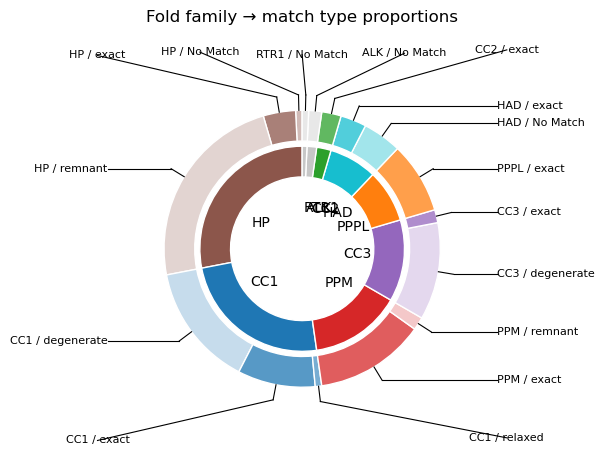

In [100]:
plot_fold_family_match_type_hierarchy(pattern_match_summary, 'motif')